In [109]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.style.use('dark_background')

π = np.pi

In [110]:
df = pd.read_csv('path.csv')

# df = df.iloc[:38,:]
df = df.iloc[:200,:]

# df

In [111]:
# calculating the incremental distance from the cumulative distance
df[' distance / mm'] = df[' distance / mm'].diff().fillna(0)

df['angle'] = df[' angle motors / °']
# df['angle'] = df[' angle gyro / °']

# path coordinates
df['x'] = (df[' distance / mm'] * np.sin(df['angle']/180*π)).cumsum()
df['y'] = (df[' distance / mm'] * np.cos(df['angle']/180*π)).cumsum()

def func(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

df[' distance infrared / mm'] = df[' distance infrared / %'].apply(lambda x: func(x, *[ 2.02747202e-03, -8.64875976e-02,  1.00946960e+01,  2.26888545e+01]))
df.loc[df[' distance infrared / mm'] > 1300, ' distance infrared / mm'] = np.nan

df['x infrared'] = df['x'] + ((df[' distance infrared / mm'] + 65) * np.sin(df['angle']/180*π))
df['y infrared'] = df['y'] + ((df[' distance infrared / mm'] + 65) * np.cos(df['angle']/180*π))

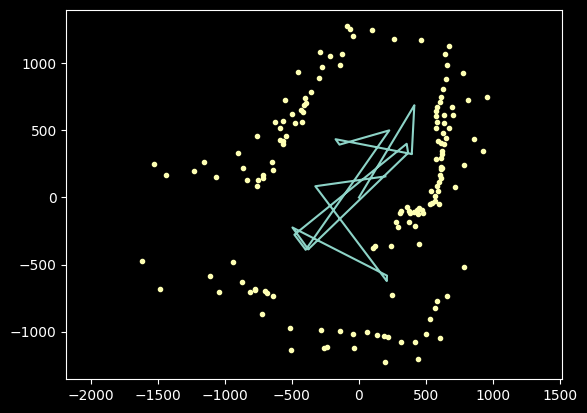

In [112]:
plt.plot(df['x'], df['y'])
plt.plot(df['x infrared'], df['y infrared'], '.')
plt.axis('equal')
plt.show()

# plt.savefig('path.png', transparent=True)

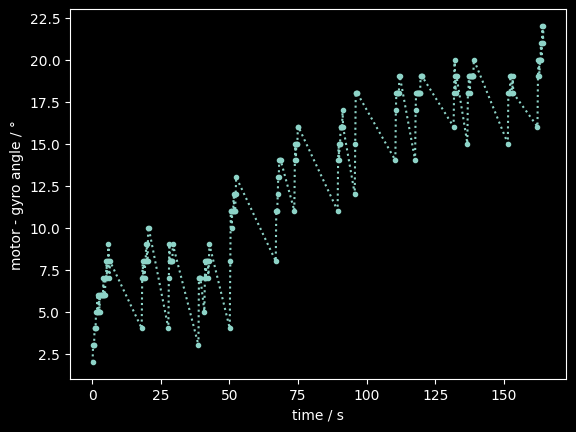

In [114]:
plt.plot(df['time / s'], (df[' angle motors / °'] - df[' angle gyro / °']) , '.:' )
plt.xlabel('time / s')
plt.ylabel('motor - gyro angle / °')
# plt.xticks([x*60  for x in range(0,14)])
# plt.yticks([x*90 for x in range(0,3)])
plt.show()

In [113]:
# plt.plot(df['time / s'], df[' angle motors / °'] , '-', label = 'motors')
# plt.plot(df['time / s'], df[' angle gyro / °']   , '-', label = 'gyro' )
# plt.legend()
# plt.xlabel('time / s')
# plt.ylabel('angle / °')
# # plt.xticks([x*60  for x in range(0,14)])
# # plt.yticks([x*360 for x in range(0,15)])
# plt.show()

# plt.savefig('angles.png', transparent=True)